# One event, two detectors — HeRALD (superfluid helium) and a water-Cherenkov tank (LUCiD)

This notebook really imports the two simulation stacks, pushes **one event** through each, and then moves
**one thing at a time** — the physics of the event, the detector geometry, the noise — and shows what
changed and why. It is the hands-on companion to `docs/LATENT_MONITORING_PLAN_2026-09-05.md` §5 (the
one-factor-per-cell discipline) and `docs/EXPERIMENT_PLAN_ARMS_2026-09-05.md` §§3–4.

| arm | what simulates the physics | what makes the trace | what adds the noise |
|---|---|---|---|
| **HeRALD** | HeST (yields + quasiparticle evaporation), pinned, unpatched | `qp_simulator.QPSimulator` | `noise_module.TESNoiseBudget` + `MultiChannelNoiseGenerator` |
| **LUCiD** | LUCiD (JAX photon transport, `hit_mode='waveform'`) | LUCiD's own 1 ns-binned photoelectron waveform → an SPE voltage template | `noise_module` composite PMT front-end preset + `MultiChannelNoiseGenerator` |

> **Where the code lives.** `herald_simulation` is a package in this repo. There is deliberately **no**
> `lucid_simulation` package yet: LUCiD ships without a licence file (gate A0 in the arms plan), so this
> notebook imports LUCiD from an external clone the same way `herald_simulation` imports HeST, and builds
> the PMT noise preset *in the notebook*. Nothing from LUCiD is vendored.

**Setup.** From the repository root:
```bash
bash src/herald_simulation/fetch_hest.sh          # pins HeST into src/herald_simulation/external/HeST
pip install qetpy numba pyarrow jax jaxlib flax optax h5py ipython
git clone https://github.com/CIDeR-ML/LUCiD external/LUCiD   # or set LUCID_PATH
```


In [1]:
import os, sys, time, json
from pathlib import Path
os.environ.setdefault("JAX_PLATFORMS", "cpu")          # LUCiD runs on CPU here; a GPU is picked up automatically if visible

# --- locate the repository root (the folder that holds src/) and the two external clones
here = Path.cwd()
ORACLE = next(p for p in [here, *here.parents] if (p / "src" / "noise_module").is_dir())
sys.path.insert(0, str(ORACLE / "src"))
LUCID = Path(os.environ.get("LUCID_PATH", ORACLE / "external" / "LUCiD"))
assert (LUCID / "lucid").is_dir(), f"LUCiD clone not found at {LUCID}; set LUCID_PATH"
sys.path.insert(0, str(LUCID))

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq

# fixed categorical order (validated palette): blue, orange, aqua, yellow
PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#9a9a95",
                     "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
                     "axes.titlecolor": "#0b0b0b", "lines.linewidth": 1.4, "font.size": 9})

import herald_simulation as hs
from herald_simulation.noise import sigma_cells
from herald_simulation.interventions import Structural
from noise_module import HERALD_V1_PLACEHOLDER, MultiChannelNoiseGenerator, NoiseGenerator, TESNoiseBudget
from latent_monitor.whitening import KroneckerWhitener, estimate_kronecker
print("ORACLE:", ORACLE); print("HeST available:", hs.available(), hs.hest_commit()); print("LUCiD:", LUCID)

ORACLE: /home/claude/oracle


HeST available: True 8ffd23e82dedbfbf531bb3ac58e789a81fd6e764
LUCiD: /tmp/claude-0/-home-claude/15017658-0894-552d-b60b-c9837edcd9c5/scratchpad/lucid/LUCiD


---
## Part A — HeRALD: one quantum-evaporation event

### A1. The reference event

`event_id = 7`, a **1 keV nuclear recoil** at (0, 0, 2) cm in the `HeRALD_v1` cell (24 CPD sensors, 1 cm²
each, 1.1 cm pitch, 5.2 cm above the floor; liquid fills to 4.8 cm). The chain is:

1. `hs.quanta(E, "NR")` — HeST partitions the deposit into quasiparticles / IR / singlet / triplet;
2. `hs.evaporate(...)` — HeST launches the quasiparticles isotropically and ray-traces them until one evaporates a helium atom onto a sensor (or dies);
3. `hs.clean_traces(...)` — every arrival becomes one single-QP template in `QPSimulator` (50 µs rise, 3 ms decay, 250 kHz × 16 384 samples);
4. `hs.add_noise(...)` — the TES budget, one shared+private structure per cell, Σ̂ and Σ recorded.

We thin the quasiparticle population to 2 % for speed (`qp_fraction`) and scale the amplitude back by 50; the *arrival-time distribution* is unaffected and the thinning is written into the provenance.

In [2]:
QP_FRACTION = 0.02
FS = 2.5e5
tcfg = hs.TraceConfig(amplitude_scale=1.0 / QP_FRACTION)

g24 = hs.shipped("HeRALD_v1")
y = hs.quanta(1000.0, "NR")
print("yields at 1 keV NR:", y)

t0 = time.time()
ev_ref = hs.evaporate(g24, event_id=7, energy_ev=1000.0, interaction="NR", vertex_cm=(0, 0, 2.0), qp_fraction=QP_FRACTION)
print(f"simulated {ev_ref.meta['n_qp_simulated']} of {ev_ref.n_qp} quasiparticles in {time.time()-t0:.1f}s; "
      f"{ev_ref.n_detected} evaporated onto {sum(len(a) > 0 for a in ev_ref.arrival_times_us)} of {ev_ref.n_sensors} sensors")

X_clean, tmeta = hs.clean_traces(ev_ref, tcfg)
X_ref, nmeta = hs.add_noise(X_clean, hs.NoiseSpec(), FS, ev_ref.seed)
print("traces:", X_clean.shape, "| noise κ(implied vs realised) =", round(nmeta["kappa"], 3), "| mean off-diagonal corr =", round(nmeta["mean_offdiag_corr"], 3))

yields at 1 keV NR: {'quasiparticles': 900238, 'ir_photons': 11, 'singlet_photons': 18, 'triplet_molecules': 4}


simulated 18005 of 900238 quasiparticles in 8.4s; 155 evaporated onto 24 of 24 sensors
traces: (24, 16384) | noise κ(implied vs realised) = 1.169 | mean off-diagonal corr = 0.316


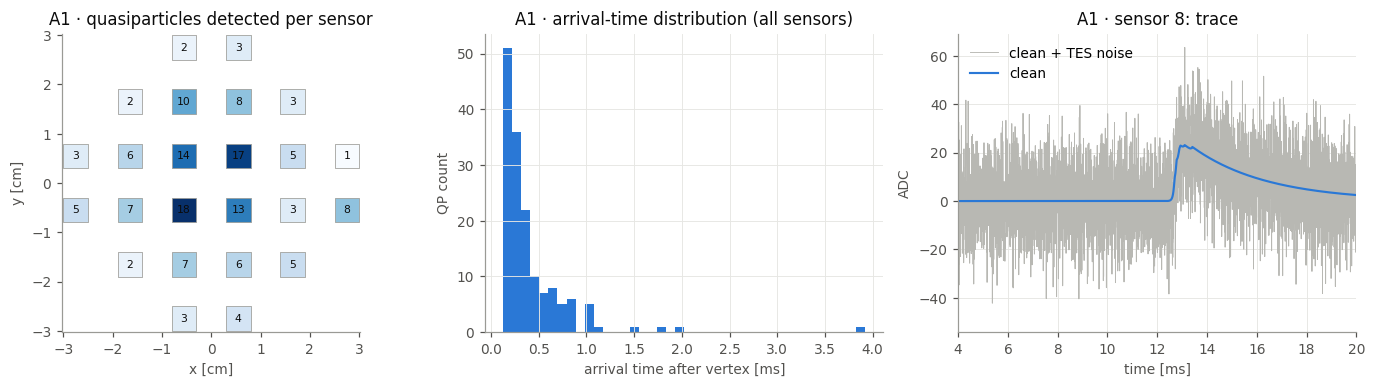

In [3]:
def sensor_map(ax, geom, values, title, cmap="Blues"):
    p = geom.positions_cm
    sc = ax.scatter(p[:, 0], p[:, 1], c=values, s=260, marker="s", cmap=cmap, edgecolor="#9a9a95", linewidth=0.5)
    for (x, y_, _z), v in zip(p, values):
        ax.text(x, y_, f"{int(v)}", ha="center", va="center", fontsize=7, color="#0b0b0b")
    ax.set_aspect("equal"); ax.set_title(title); ax.set_xlabel("x [cm]"); ax.set_ylabel("y [cm]"); ax.grid(False)
    return sc

t_ms = np.arange(tcfg.trace_samples) / FS * 1e3
counts = np.array([len(a) for a in ev_ref.arrival_times_us])
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
sensor_map(ax[0], g24, counts, "A1 · quasiparticles detected per sensor")
all_t = np.concatenate(ev_ref.arrival_times_us)
ax[1].hist(all_t / 1e3, bins=40, color=PAL[0]); ax[1].set_xlabel("arrival time after vertex [ms]"); ax[1].set_ylabel("QP count"); ax[1].set_title("A1 · arrival-time distribution (all sensors)")
best = int(np.argmax(counts))
ax[2].plot(t_ms, X_ref[best], color="#b8b8b3", lw=0.6, label="clean + TES noise")
ax[2].plot(t_ms, X_clean[best], color=PAL[0], label="clean")
ax[2].set_xlim(4, 20); ax[2].set_xlabel("time [ms]"); ax[2].set_ylabel("ADC"); ax[2].set_title(f"A1 · sensor {best}: trace"); ax[2].legend(frameon=False)
plt.tight_layout()

What you are looking at: the event sits at the axis, so the sensor map is roughly symmetric; the arrival
times spread over a few milliseconds because quasiparticles bounce off the walls (30 % specular, diffuse
otherwise) before they reach the surface with enough momentum to evaporate; and the trace is a pile-up of
many single-QP templates riding on the TES noise. The κ printed above is the **matched-cell estimator
floor** — implied and realised covariance of the *same* generator differ by ~1.2 at N/C = 683, and any
mismatch we inject later has to be read against that floor.

### A2. Move the physics only — same `event_id`, same geometry, same noise

Three changes, one at a time: nuclear → electron recoil at the same energy; double the energy; move the
vertex off-axis. Because `hs.evaporate` seeds HeST from `event_id`, the *first* `n` quasiparticles are the
same draws in every case — only their number and origin change.

ref  NR 1 keV @(0,0,2)           n_QP=  900238  simulated= 18005  detected= 155  peak ADC (summed) =    183.7


ER   1 keV @(0,0,2)              n_QP=  419925  simulated=  8398  detected=  68  peak ADC (summed) =     79.8


NR   2 keV @(0,0,2)              n_QP= 1629910  simulated= 32598  detected= 288  peak ADC (summed) =    343.3


NR   1 keV @(2,0,2) off-axis     n_QP=  900238  simulated= 18005  detected= 118  peak ADC (summed) =    139.3


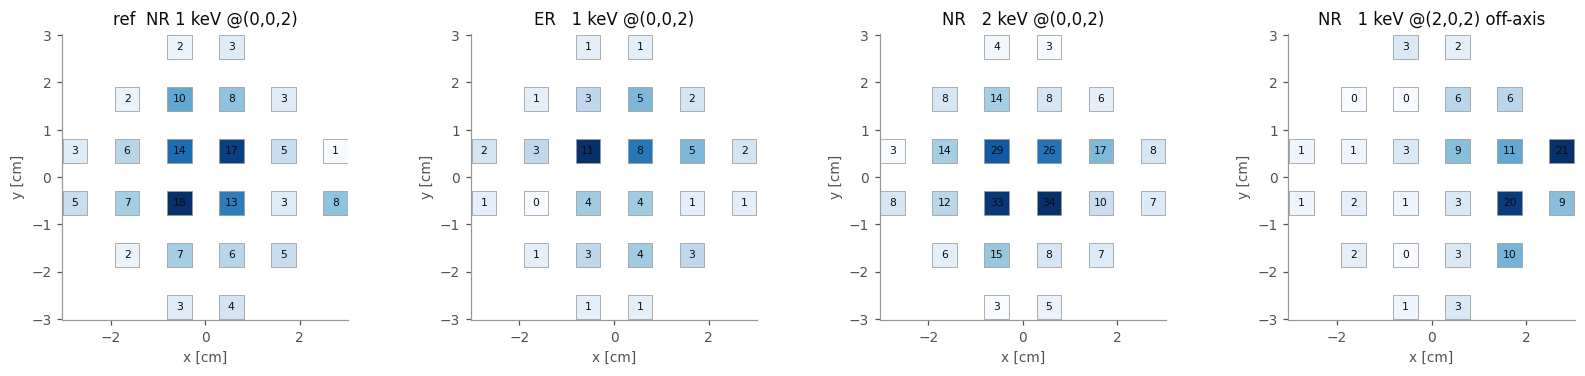

In [4]:
variants = {
    "ref  NR 1 keV @(0,0,2)":     dict(energy_ev=1000.0, interaction="NR", vertex_cm=(0, 0, 2.0)),
    "ER   1 keV @(0,0,2)":        dict(energy_ev=1000.0, interaction="ER", vertex_cm=(0, 0, 2.0)),
    "NR   2 keV @(0,0,2)":        dict(energy_ev=2000.0, interaction="NR", vertex_cm=(0, 0, 2.0)),
    "NR   1 keV @(2,0,2) off-axis": dict(energy_ev=1000.0, interaction="NR", vertex_cm=(2.0, 0, 2.0)),
}
events = {}
for name, kw in variants.items():
    ev = hs.evaporate(g24, event_id=7, qp_fraction=QP_FRACTION, **kw)
    Xc, _ = hs.clean_traces(ev, tcfg)
    events[name] = (ev, Xc)
    print(f"{name:32s} n_QP={ev.n_qp:8d}  simulated={ev.meta['n_qp_simulated']:6d}  detected={ev.n_detected:4d}  "
          f"peak ADC (summed) = {Xc.sum(0).max():8.1f}")

fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
for a, (name, (ev, Xc)) in zip(ax, events.items()):
    sensor_map(a, g24, np.array([len(t) for t in ev.arrival_times_us]), name)
plt.tight_layout()

How to read the deltas:

* **NR → ER at the same energy** halves the quasiparticle count (HeST's yield model puts far more of an
  electron recoil's energy into photons and triplet molecules), so every sensor sees about half the hits and the
  summed trace amplitude halves. *The shape of the arrival-time distribution does not change* — that is the
  signature of a physics (event-type) change: it lives in the amplitude and in the yield partition, not in the
  detector's response.
* **Doubling the energy** doubles the quasiparticle population; the detected count and amplitude scale
  linearly. Same spatial pattern.
* **Moving the vertex** to x = 2 cm shifts the detected pattern toward the sensors above it and lengthens the
  path to the far side; the total count barely changes. This is what a *geometry-side* change looks like when
  the geometry is fixed and the event moves — the pattern, not the count.

### A3. Move the geometry only — same event through three cells

`hs.evaporate` seeds NumPy from `event_id` **before** HeST samples the initial population, and HeST samples
directions and momenta before it looks at the geometry — so the same quasiparticles fly in all three
detectors. `hs.initial_population` reproduces the seed and lets us check that literally.

HeRALD_v1 (24)     sensors=24 detected= 155  per-sensor max= 18


3×3 custom (9)     sensors= 9 detected= 106  per-sensor max= 21


monolithic (1)     sensors= 1 detected= 207  per-sensor max=207
initial quasiparticle momenta identical across the three geometries: True


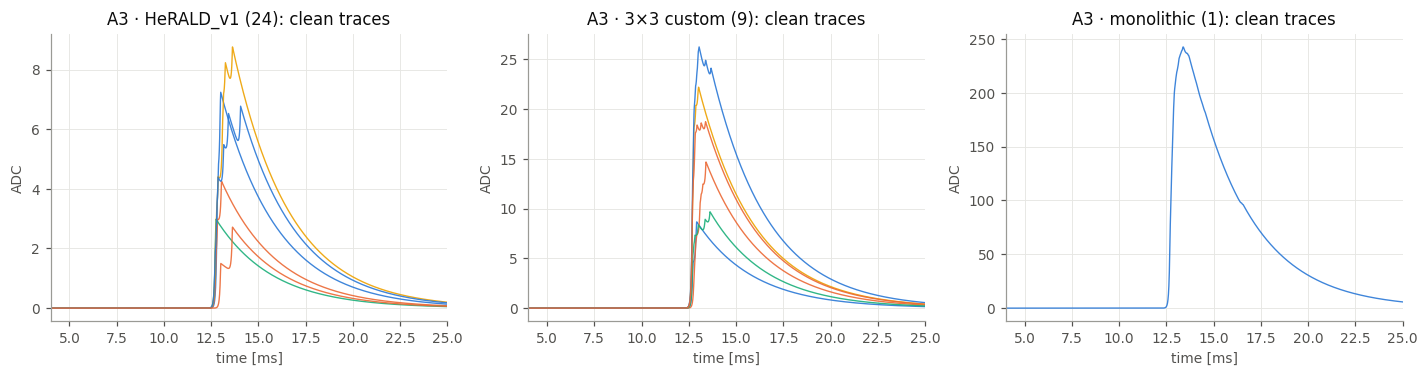

In [5]:
g1 = hs.shipped("HeRALD_v1_monolithic")            # one sensor covering the whole top
g9 = hs.make_cell(array_map=np.ones((3, 3)), name="cell_3x3")   # a custom 3×3 array from HeST's own primitives
geoms = {"HeRALD_v1 (24)": g24, "3×3 custom (9)": g9, "monolithic (1)": g1}
pop = {}
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
for a, (name, g) in zip(ax, geoms.items()):
    ev = hs.evaporate(g, event_id=7, energy_ev=1000.0, interaction="NR", vertex_cm=(0, 0, 2.0), qp_fraction=QP_FRACTION)
    pop[name] = hs.initial_population(7, ev.meta["n_qp_simulated"])
    Xc, _ = hs.clean_traces(ev, tcfg)
    print(f"{name:18s} sensors={g.n_sensors:2d} detected={ev.n_detected:4d}  per-sensor max={max(len(t) for t in ev.arrival_times_us):3d}")
    for c in range(min(g.n_sensors, 6)):
        a.plot(t_ms, Xc[c], lw=0.9, color=PAL[c % 4] if g.n_sensors > 1 else PAL[0], alpha=0.9)
    a.set_xlim(4, 25); a.set_title(f"A3 · {name}: clean traces"); a.set_xlabel("time [ms]"); a.set_ylabel("ADC")
plt.tight_layout()
first = list(pop)[0]
print("initial quasiparticle momenta identical across the three geometries:",
      all(np.array_equal(pop[first], v) for v in pop.values()))

The last line is the pairing contract: the *same* quasiparticles in every cell. What differs is only how
the cell collects them. The monolithic sensor catches everything that reaches the top surface in one trace
(more total, no spatial information); the 24-sensor array splits the same arrivals across channels, so each
trace is smaller and the pattern carries the vertex. That is the "granularity at fixed active volume" axis
the plan uses: 24 → 9 → 1 channels on the identical helium cell.

### A4. Move the noise only — same event, same geometry, four noise models

`herald_simulation.noise.sigma_cells` gives four Σ̂ ≠ Σ cells relative to the reference TES budget:
stronger bath-fluctuation correlation, low-rank pickup modes, a SQUID 1/f knee ten times higher, and
mains pickup eight times stronger. We keep the *same* clean traces and only change the noise, then compare
the noise-only spectra and the channel-correlation matrices, and quote κ(Σ̂_ref⁻¹ Σ_cell) — how far each
cell's realised covariance is from what a model trained on the reference would assume.

reference      κ_channel= 1.16  κ_temporal=  2.44  κ=   2.84   mean off-diag corr=0.316
bath_corr_up   κ_channel= 5.41  κ_temporal=  5.38  κ=  29.14   mean off-diag corr=0.711
pickup_modes   κ_channel=37.14  κ_temporal=  2.04  κ=  75.62   mean off-diag corr=-0.003
squid_knee_up  κ_channel= 1.16  κ_temporal=  3.59  κ=   4.18   mean off-diag corr=0.316
mains_up       κ_channel= 1.16  κ_temporal=  2.44  κ=   2.84   mean off-diag corr=0.316


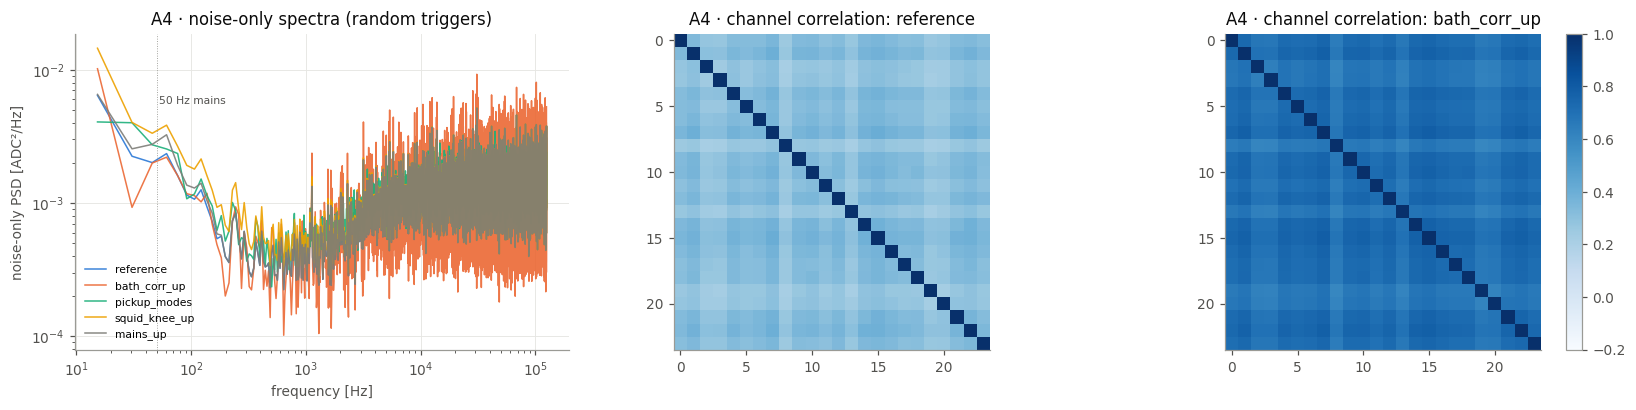

In [6]:
N = tcfg.trace_samples
specs = {"reference": hs.NoiseSpec(), **{s.label: s for s in sigma_cells(hs.NoiseSpec())}}
noisy, meta, noise_only = {}, {}, {}
for name, spec in specs.items():
    Xn, m = hs.add_noise(X_clean, spec, FS, ev_ref.seed)
    N0, _ = hs.add_noise(np.zeros_like(X_clean), spec, FS, ev_ref.seed + 1)   # a random trigger: no event
    noisy[name], meta[name], noise_only[name] = Xn, m, N0

# the reference model's assumed Σ̂ as a Kronecker whitener: channel factor from the implied covariance, temporal from the budget
ref_base = specs["reference"].base_config(FS, N)
_, S_ref = NoiseGenerator(ref_base).build_psd_density(N)
Sc_ref = meta["reference"]["implied_covariance"]; Sc_ref = Sc_ref / np.mean(np.diag(Sc_ref))
W_ref = KroneckerWhitener(Sc_ref, S_ref, FS, N)

f = rfftfreq(N, d=1 / FS)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for i, name in enumerate(specs):
    psd = np.mean(np.abs(rfft(noise_only[name], axis=-1)) ** 2, axis=0) * 2 / (FS * N)
    ax[0].loglog(f[1:], psd[1:], lw=1.0, color=PAL[i % 4] if i < 4 else "#7d7d78", label=name, alpha=0.9)
    Sc_cell, S_cell = estimate_kronecker(noise_only[name][None], FS, psd_smoothing=9)
    k = W_ref.kappa_against(Sc_cell, S_cell)
    print(f"{name:14s} κ_channel={k['kappa_channel']:5.2f}  κ_temporal={k['kappa_temporal']:6.2f}  κ={k['kappa']:7.2f}   mean off-diag corr={m['mean_offdiag_corr'] if (m:=meta[name]) else 0:.3f}")
ax[0].set_xlabel("frequency [Hz]"); ax[0].set_ylabel("noise-only PSD [ADC²/Hz]"); ax[0].set_title("A4 · noise-only spectra (random triggers)"); ax[0].legend(frameon=False, fontsize=7)
ax[0].axvline(50, color="#9a9a95", lw=0.6, ls=":"); ax[0].text(52, ax[0].get_ylim()[1] * 0.3, "50 Hz mains", fontsize=7, color="#52514e")
for a, name in zip(ax[1:], ["reference", "bath_corr_up"]):
    C_ = np.corrcoef(noise_only[name]); im = a.imshow(C_, vmin=-0.2, vmax=1, cmap="Blues"); a.set_title(f"A4 · channel correlation: {name}"); a.grid(False)
plt.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout()

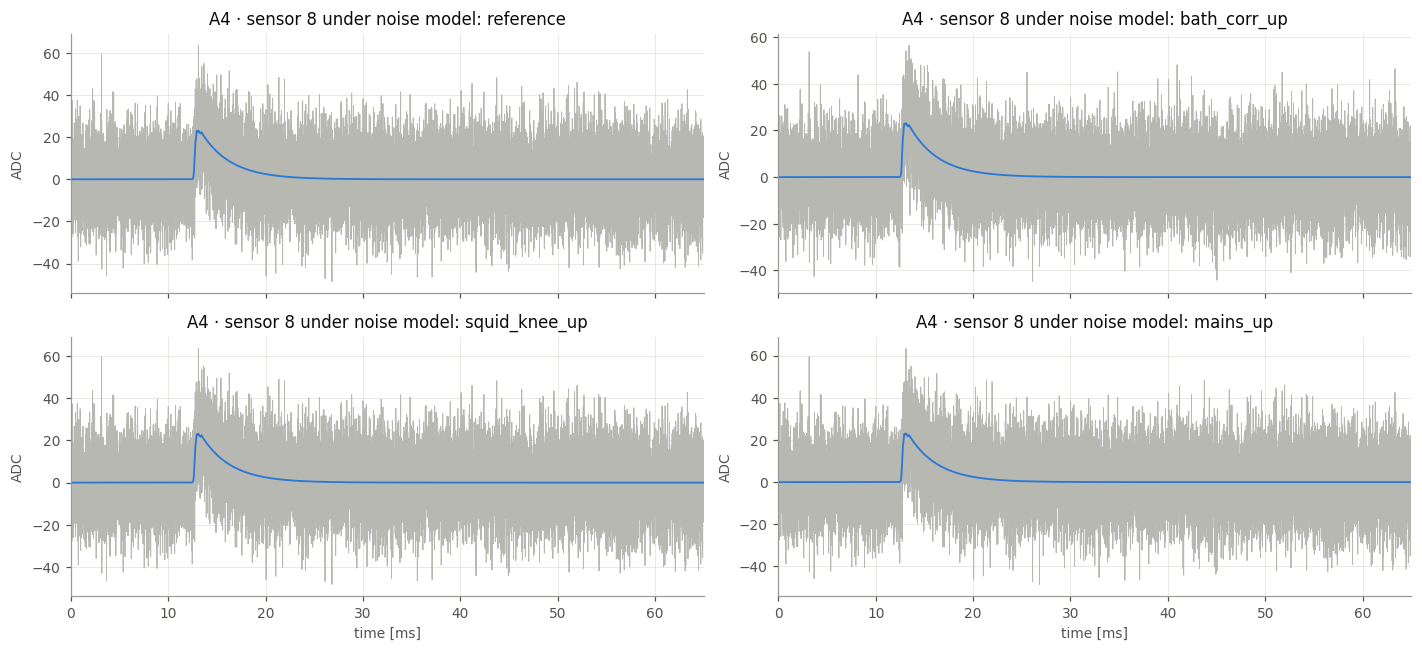

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
for a, name in zip(ax.ravel(), ["reference", "bath_corr_up", "squid_knee_up", "mains_up"]):
    a.plot(t_ms, noisy[name][best], color="#b8b8b3", lw=0.6)
    a.plot(t_ms, X_clean[best], color=PAL[0], lw=1.2)
    a.set_xlim(0, 65); a.set_title(f"A4 · sensor {best} under noise model: {name}"); a.set_ylabel("ADC")
for a in ax[1]: a.set_xlabel("time [ms]")
plt.tight_layout()

About the κ column first. Here κ is estimated from **one** 65 ms record against the *analytic* reference
spectrum, so even the reference row does not read 1 — its κ_temporal ≈ 2.4 is the estimator floor of a
single periodogram with 1/f and lines in it, and κ_channel ≈ 1.2 is the N/C = 683 floor the arms plan
predicted. Read the other rows relative to those. Two more honest caveats: the periodogram is smoothed over
9 bins (140 Hz), which is why `mains_up` — a 15 Hz-wide line — leaves κ_temporal unchanged even though it
is plainly visible in the spectrum (the monitoring package keeps a separate single-bin line statistic for
exactly this reason); and `pickup_modes` has a *mean* off-diagonal correlation of ~0 yet κ_channel ≈ 37,
because its low-rank pickup has random signs across channels — the mean correlation is a bad summary of a
structured covariance, and κ is the right one.

What changed, and how you can tell which knob moved:

* **`bath_corr_up`** — the channel-correlation matrix fills in (every CPD sits on the same cold stage and
  sees the same bath-temperature fluctuation); the per-channel spectrum is unchanged. κ_channel moves,
  κ_temporal does not. On a single trace you cannot see it at all — it is a *between-channel* change.
* **`squid_knee_up`** — the SQUID's 1/f corner moves from 100 Hz to 1 kHz, so the low-frequency end of every
  spectrum rises. κ_temporal moves; the correlation matrix does not. On a trace it looks like slow wander
  under the pulse.
* **`mains_up`** — one narrow feature grows at 50 Hz (and 100, 150 Hz). Nothing else changes. This is the
  narrowest possible spectral change and the hardest to see in the time domain, because at 250 kHz sampling a
  50 Hz line is a 20 ms wiggle — visible only because the record is 65 ms long. (On LUCiD's 512 ns record it
  would not exist; see Part B.)
* **`pickup_modes`** — a few latent modes shared by every channel (low-rank structure): the correlation matrix
  becomes rank-limited rather than uniform.

None of these touched the clean trace. That is the whole point of a Σ-cell: the physics is identical, the
detector's response is identical, only the acquisition-side covariance moved — and it moved in a way that a
*random trigger* (a record with no event in it) already reveals.

### A5. A structural intervention, for contrast

The last kind of change is N by contract but not covariance-type: losing sensors, gain drift, timing jitter.
These are applied to the acquired trace — signal *and* noise — so they show up in random triggers too, but
they also move the event's mean pattern.

sensor_loss zeroes a quarter of the channels; gain_drift multiplies each channel by 1+N(0,0.15); timing_jitter rolls each channel by up to ±8 samples (±32 µs) — invisible at this pulse width, but it decorrelates a shared noise component, which is why the monitoring table classifies it as a covariance change.


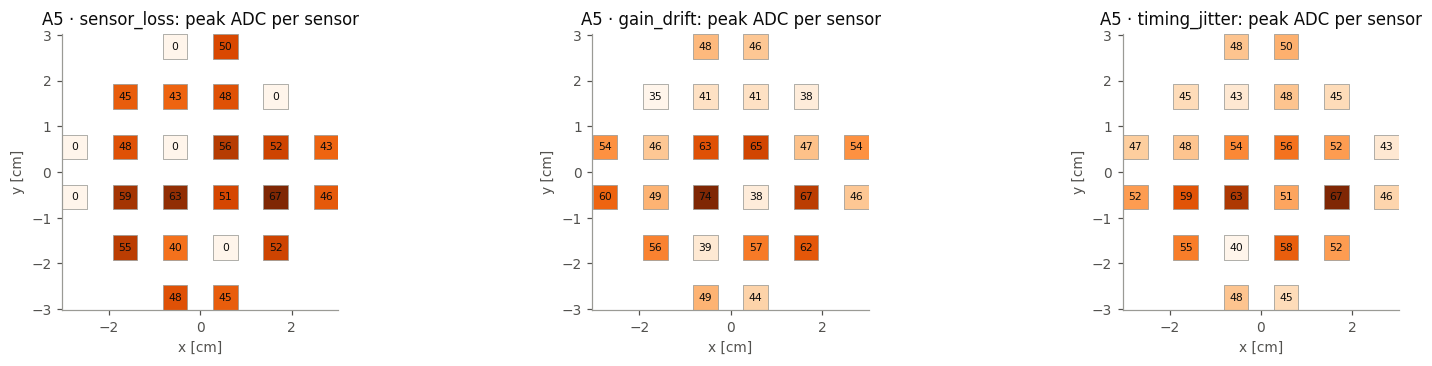

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
for a, kind in zip(ax, ["sensor_loss", "gain_drift", "timing_jitter"]):
    Xs = Structural(kind).apply(X_ref, ev_ref.seed)
    per_sensor_peak = Xs.max(axis=1)
    sensor_map(a, g24, np.round(per_sensor_peak), f"A5 · {kind}: peak ADC per sensor", cmap="Oranges")
plt.tight_layout()
print("sensor_loss zeroes a quarter of the channels; gain_drift multiplies each channel by 1+N(0,0.15); "
      "timing_jitter rolls each channel by up to ±8 samples (±32 µs) — invisible at this pulse width, "
      "but it decorrelates a shared noise component, which is why the monitoring table classifies it as a covariance change.")

---
## Part B — LUCiD: one light event in a water-Cherenkov tank

### B1. The reference event

LUCiD does not simulate a neutrino interaction; it transports **photons**. For a self-contained event we use
its built-in **isotropic calibration source** (a flasher at the centre, 50 000 photons) inside the
`WCTE_like` cylinder (r = 2 m, H = 4 m, ~2 444 PMTs of 4 cm radius), in `hit_mode='waveform'`: every
detected photon is QE-thinned, smeared by the transit-time spread, gain-smeared, and binned into a
`(n_sensors, n_bins)` array at **1 ns** — "1 GHz FADC convention". That array is what makes LUCiD the
only water-Cherenkov package on which a PSD-based noise model can be applied at all.

Two things to know about running it: `temperature=None` selects the hard-step overlap mode, which avoids a
9.5 GB look-up table the soft mode builds on first use; and the first call compiles the JAX program
(a few seconds), after which the same simulator re-runs a new source in milliseconds.

In [9]:
import jax
from lucid.geometry import generate_detector
from lucid.simulation import setup_event_simulator
from lucid.sources import isotropic_source

CFG = LUCID / "config"
def lucid_sim(geom_name, n_photons=50_000, window_ns=512.0, bin_ns=1.0):
    geom, phys = CFG / f"{geom_name}_geom_config.json", CFG / f"{geom_name}_physics_config.json"
    det = generate_detector(str(geom))
    sim = setup_event_simulator(str(geom), n_photons, temperature=None, K=6, is_calibration=True, hit_mode="waveform",
                                physics_config=str(phys), default_detector_params=True, wavelength_mode=False,
                                waveform_config=dict(window_ns=window_ns, bin_width_ns=bin_ns))
    return det, sim

t0 = time.time()
det_w, sim_w = lucid_sim("WCTE_like")
pos = np.asarray(det_w.all_points)          # (n_sensors, 3) PMT positions in metres
src = isotropic_source(position=[0.0, 0.0, 0.0], intensity=50_000)
wf_ref = np.asarray(sim_w(src, jax.random.PRNGKey(0))[0])   # (n_sensors, n_bins) photoelectrons per 1 ns bin
print(f"WCTE_like: {pos.shape[0]} PMTs placed, waveform {wf_ref.shape}, {time.time()-t0:.1f}s incl. JIT; "
      f"total {wf_ref.sum():.0f} pe on {(wf_ref.sum(1) > 0).sum()} PMTs; first light in bin {int(np.argmax(wf_ref.sum(0) > 0))}")

/tmp/claude-0/-home-claude/15017658-0894-552d-b60b-c9837edcd9c5/scratchpad/lucid/LUCiD/lucid/overlap.py:160: DeprecationWarning: backend and device argument on jit is deprecated. You can use `jax.device_put(..., jax.local_devices(backend="cpu")[0])` on the inputs to the jitted function to get the same behavior.
  @partial(jax.jit, device=jax.devices('cpu')[0])
/tmp/claude-0/-home-claude/15017658-0894-552d-b60b-c9837edcd9c5/scratchpad/lucid/LUCiD/lucid/propagation/cylinder.py:530: DeprecationWarning: backend and device argument on jit is deprecated. You can use `jax.device_put(..., jax.local_devices(backend="cpu")[0])` on the inputs to the jitted function to get the same behavior.
  @partial(jax.jit, static_argnums=(2, 3, 4, 5, 6), device=jax.devices('cpu')[0])
/tmp/claude-0/-home-claude/15017658-0894-552d-b60b-c9837edcd9c5/scratchpad/lucid/LUCiD/lucid/propagation/sphere.py:326: DeprecationWarning: backend and device argument on jit is deprecated. You can use `jax.device_put(..., jax.lo

WCTE_like: 2444 PMTs placed, waveform (2444, 512), 6.9s incl. JIT; total 16213 pe on 2440 PMTs; first light in bin 6


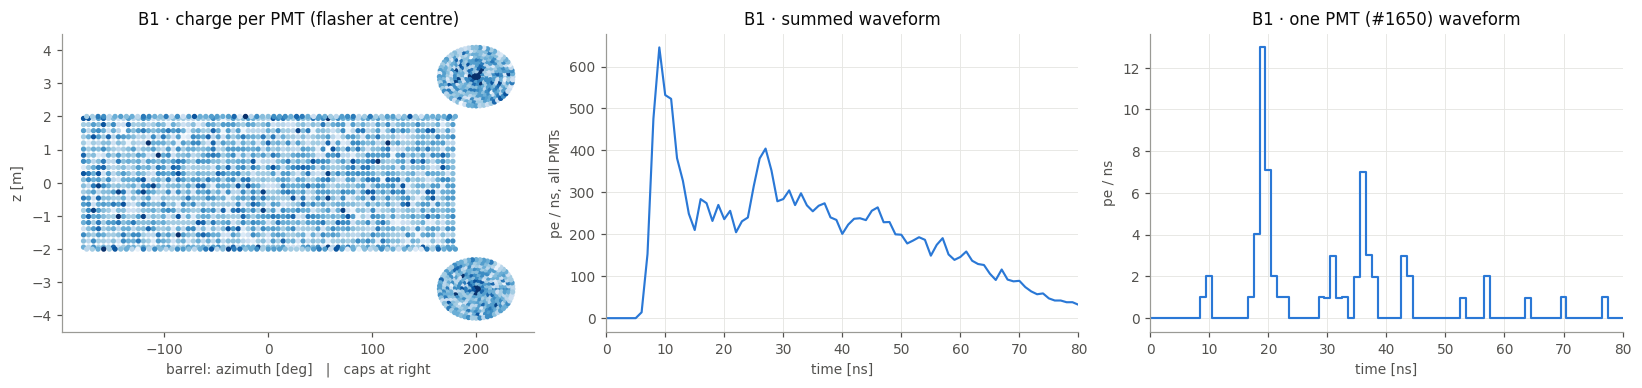

In [10]:
def pmt_map(ax, pos, values, title, cmap="Blues"):
    """Unwrap the cylinder: barrel by azimuth vs z, caps by x vs y — one scatter per surface."""
    r = np.hypot(pos[:, 0], pos[:, 1]); zmax = np.abs(pos[:, 2]).max()
    barrel = r > 0.9 * r.max(); top = (~barrel) & (pos[:, 2] > 0); bot = (~barrel) & (pos[:, 2] <= 0)
    phi = np.degrees(np.arctan2(pos[:, 1], pos[:, 0]))
    vmax = np.percentile(values[values > 0], 99) if (values > 0).any() else 1
    ax.scatter(phi[barrel], pos[barrel, 2], c=values[barrel], s=6, cmap=cmap, vmin=0, vmax=vmax)
    ax.scatter(phi[top] * 0 + 200 + pos[top, 0] * 20, pos[top, 1] * 0.5 + zmax + 1.2, c=values[top], s=6, cmap=cmap, vmin=0, vmax=vmax)
    ax.scatter(phi[bot] * 0 + 200 + pos[bot, 0] * 20, pos[bot, 1] * 0.5 - zmax - 1.2, c=values[bot], s=6, cmap=cmap, vmin=0, vmax=vmax)
    ax.set_title(title); ax.set_xlabel("barrel: azimuth [deg]   |   caps at right"); ax.set_ylabel("z [m]"); ax.grid(False)

charge = wf_ref.sum(axis=1)
tb = np.arange(wf_ref.shape[1])
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
pmt_map(ax[0], pos, charge, "B1 · charge per PMT (flasher at centre)")
ax[1].plot(tb, wf_ref.sum(0), color=PAL[0]); ax[1].set_xlim(0, 80); ax[1].set_xlabel("time [ns]"); ax[1].set_ylabel("pe / ns, all PMTs"); ax[1].set_title("B1 · summed waveform")
hot = int(np.argmax(charge))
ax[2].step(tb, wf_ref[hot], where="mid", color=PAL[0]); ax[2].set_xlim(0, 80); ax[2].set_xlabel("time [ns]"); ax[2].set_ylabel("pe / ns"); ax[2].set_title(f"B1 · one PMT (#{hot}) waveform")
plt.tight_layout()

A flasher at the centre lights the whole tank almost uniformly — the barrel at 2 m is hit first (~7 ns at
water's group velocity), the caps at 2 m in z at about the same time, so the summed waveform is one sharp
front with a scattering tail. A single PMT sees a handful of photoelectrons in a few adjacent 1 ns bins. This
is a *photoelectron count histogram*, not a voltage: that matters in B4.

### B2. Move the source only — position and intensity

ref  centre, 5e4 rays      total    16306 pe  PMTs lit  2442  first light at 5 ns  max PMT 65.9 pe


moved (0.8, 0, 1.0) m      total    16438 pe  PMTs lit  2438  first light at 1 ns  max PMT 21.0 pe


centre, ×3 rays            total    48985 pe  PMTs lit  2444  first light at 5 ns  max PMT 169.0 pe


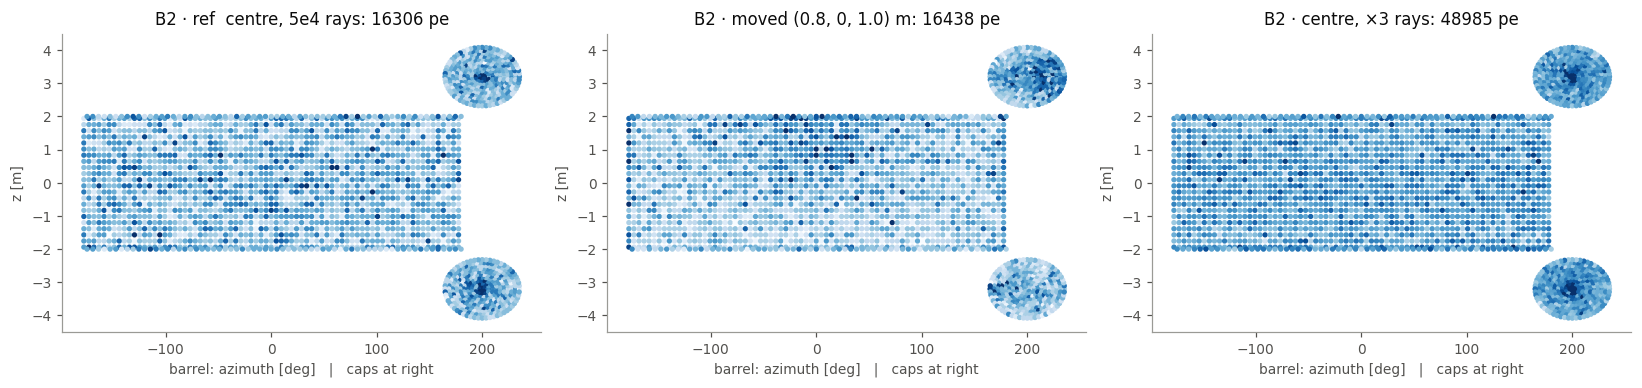

In [11]:
# NB: the photon budget is the simulator's n_photons (the number of rays traced); the source's
# `intensity` is a weight the calibration fitter uses. To brighten the flasher, trace more rays.
_, sim_w3 = lucid_sim("WCTE_like", n_photons=150_000)
cases = {"ref  centre, 5e4 rays": (sim_w, [0.0, 0.0, 0.0]),
         "moved (0.8, 0, 1.0) m": (sim_w, [0.8, 0.0, 1.0]),
         "centre, ×3 rays": (sim_w3, [0.0, 0.0, 0.0])}
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a, (name, (simx, p)) in zip(ax, cases.items()):
    wf = np.asarray(simx(isotropic_source(position=p, intensity=50_000), jax.random.PRNGKey(1))[0])
    q = wf.sum(1)
    pmt_map(a, pos, q, f"B2 · {name}: {q.sum():.0f} pe")
    first = int(np.argmax(wf.sum(0) > 0)); print(f"{name:26s} total {q.sum():8.0f} pe  PMTs lit {int((q>0).sum()):5d}  first light at {first} ns  max PMT {q.max():.1f} pe")
plt.tight_layout()

Moving the source off-centre makes the charge map lopsided (near PMTs bright and early, far ones dim and
late) and brings the first light earlier — the source is now 1.2 m from the nearest wall. Tracing three
times as many rays leaves the *pattern* and the *timing* as in the reference and multiplies every charge by
about three: the LUCiD analogue of HeRALD's "double the energy". Pattern + timing = where; amplitude = how
much. (A LUCiD detail worth knowing: the light level is the simulator's `n_photons` ray budget, not the
source's `intensity`, which is a fit weight.)

### B3. Move the geometry only — same source, three tanks

LUCiD's geometry is one JSON file. We run the identical flasher through the cylinder (`WCTE_like`), a box
(`MidBox`), and the same cylinder with a third of the PMTs — a config written on the fly, which is exactly
how the granularity axis in the arms plan is instantiated.

WCTE_like (cylinder)     PMTs placed  2444  total    16213 pe  mean pe/PMT  6.63  4.1s


WCTE sparse (800 PMTs)   PMTs placed   782  total     6025 pe  mean pe/PMT  7.70  4.8s


MidBox (box)             PMTs placed  8932  total    32065 pe  mean pe/PMT  3.59  6.1s


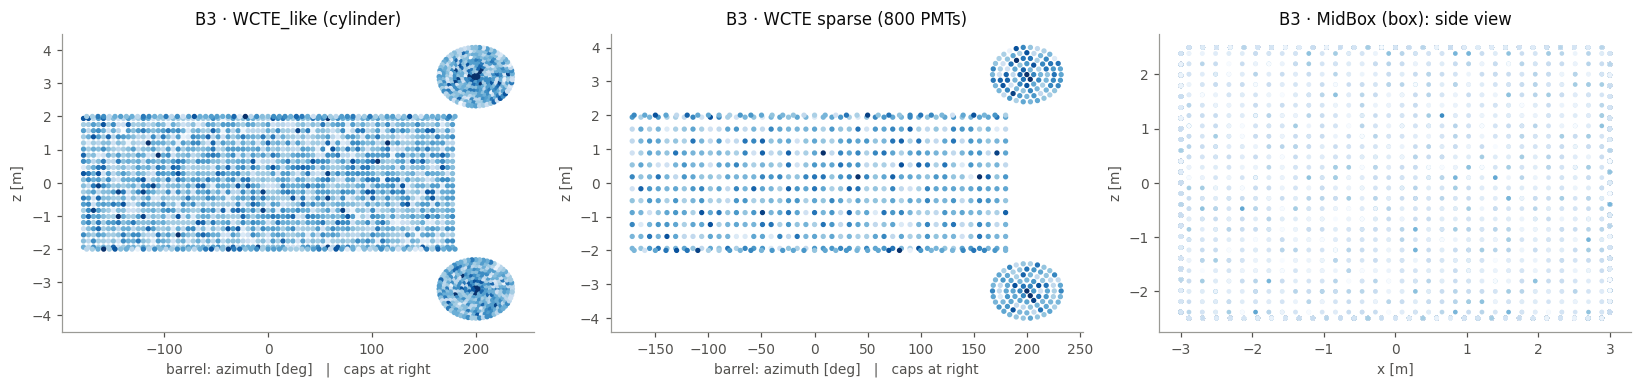

In [12]:
import tempfile, shutil
sparse_dir = Path(tempfile.mkdtemp()); (sparse_dir).mkdir(exist_ok=True)
cfg = json.loads((CFG / "WCTE_like_geom_config.json").read_text()); cfg["geometry_definitions"]["n_sensors"] = 800
(sparse_dir / "WCTE_sparse_geom_config.json").write_text(json.dumps(cfg)); shutil.copy(CFG / "WCTE_like_physics_config.json", sparse_dir / "WCTE_sparse_physics_config.json")
_CFG_saved = CFG

runs = {}
for name, cfg_dir in [("WCTE_like (cylinder)", CFG), ("WCTE sparse (800 PMTs)", sparse_dir), ("MidBox (box)", CFG)]:
    CFG = cfg_dir
    gname = {"WCTE_like (cylinder)": "WCTE_like", "WCTE sparse (800 PMTs)": "WCTE_sparse", "MidBox (box)": "MidBox"}[name]
    t0 = time.time(); det, sim = lucid_sim(gname)
    wf = np.asarray(sim(isotropic_source(position=[0.0, 0.0, 0.0], intensity=50_000), jax.random.PRNGKey(0))[0])
    runs[name] = (np.asarray(det.all_points), wf)
    print(f"{name:24s} PMTs placed {wf.shape[0]:5d}  total {wf.sum():8.0f} pe  mean pe/PMT {wf.sum()/wf.shape[0]:5.2f}  {time.time()-t0:.1f}s")
CFG = _CFG_saved

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a, (name, (p, wf)) in zip(ax, runs.items()):
    if "MidBox" in name:
        q = wf.sum(1); a.scatter(p[:, 0], p[:, 2], c=q, s=4, cmap="Blues"); a.set_title(f"B3 · {name}: side view"); a.set_xlabel("x [m]"); a.set_ylabel("z [m]"); a.grid(False)
    else:
        pmt_map(a, p, wf.sum(1), f"B3 · {name}")
plt.tight_layout()

Same flasher, same rays. With a third of the PMTs at the same radius the *photocathode coverage* drops by
a third, so the tank collects about a third of the light — while the light *per PMT* barely changes (each
PMT still sees the same flux). That is what a **granularity** change at fixed active volume does: it
changes how many channels there are and how much total information the detector keeps, not what one
channel looks like — exactly what a model trained on 2 444 channels is asked to survive. The box is a
different *shape*: corners are far, faces are near, so the same rays are distributed differently and
arrive with a different time structure. Note that LUCiD only guarantees the *requested* sensor count
approximately — read the placed count from `det.all_points`, never the JSON.

### B4. Noise — from photoelectron counts to a voltage trace, then the front end

LUCiD's waveform holds **photoelectrons per bin**. Its own stochastic layer (already applied above) is
photon-counting noise: Bernoulli QE, single-photoelectron gain smearing, and transit-time spread. What it does
*not* have is any electronics: no amplifier, no cable, no digitiser, and **no covariance between channels at
all**. That is the hole `noise_module` fills, and doing it honestly takes three steps:

1. **Units bridge.** Convolve each PMT's pe-histogram with a single-photoelectron *voltage* pulse
   (2 ns rise, 8 ns fall, 4 mV per pe) — now the trace is in mV and a PSD in mV²/Hz means something.
2. **A PMT front-end spectral preset** on the 1 GHz grid: white amplifier floor, a front-end bandwidth
   roll-off at 250 MHz, a weak 1/f term, a **clock/switching pickup line** at 62.5 MHz, and cable-reflection
   ringing at 150 MHz. All of these are existing `noise_module` components — the preset is pure configuration.
3. **Channel structure.** Coherent pickup in a real tank is per crate: we group PMTs into 64-channel
   "crates" and give each group shared-private noise.

Notice what is *absent*: 50 Hz mains. On a 512 ns record the frequency resolution is 1.95 MHz — a 50 Hz line
is 2.6 × 10⁻⁵ of one bin above DC and cannot be represented. On the HeRALD record it was the loudest line.
Same physics, opposite grid.

first bin above DC: 1.9531249999999998 MHz  →  50 Hz is 2.5600000000000002e-05 of a bin: not representable on this record


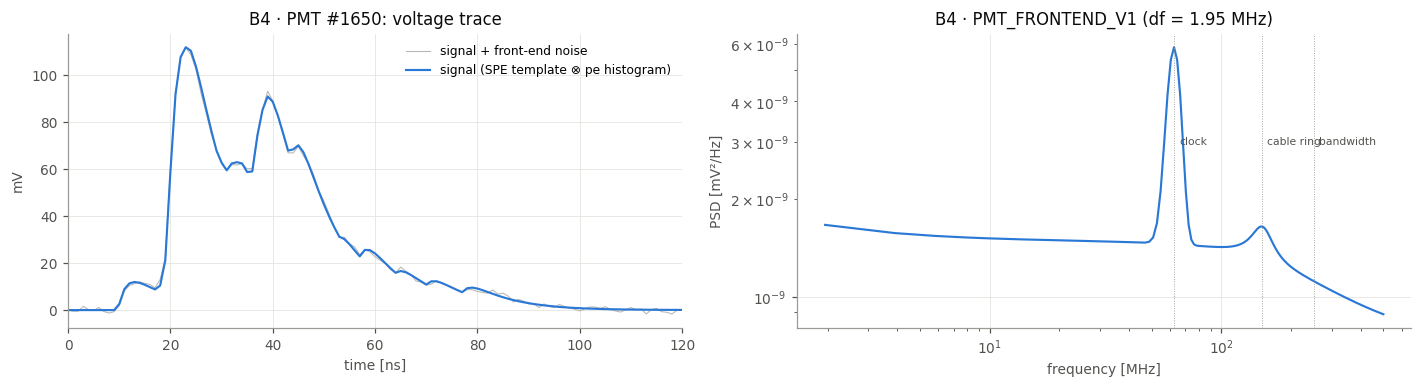

In [13]:
FS_L, N_L = 1e9, wf_ref.shape[1]
tns = np.arange(N_L) / FS_L * 1e9

# 1. units bridge: pe histogram -> mV via an SPE voltage template (two-exponential, unit area scaled to 4 mV·ns... peak-normalised to 4 mV)
def spe_template(fs=FS_L, tau_rise_ns=2.0, tau_fall_ns=8.0, mv_per_pe=4.0, length_ns=60):
    t = np.arange(int(length_ns * fs / 1e9)) / fs * 1e9
    p = (1 - np.exp(-t / tau_rise_ns)) * np.exp(-t / tau_fall_ns)
    return mv_per_pe * p / p.max()
spe = spe_template()
def to_mv(wf_pe):
    return np.stack([np.convolve(row, spe)[: wf_pe.shape[1]] for row in wf_pe])
sig_mv = to_mv(wf_ref)

# 2. the PMT front-end preset (all existing components; density normalisation, total variance set below)
PMT_FRONTEND_V1 = dict(
    noise_type="composite", sampling_frequency=FS_L, noise_power=(0.8) ** 2,   # 0.8 mV rms baseline noise
    power_definition="variance", composite_psd_scaling="normalize",
    components=[
        {"type": "white",     "scale": 1.0,  "name": "amplifier_floor"},
        {"type": "rolloff",   "scale": 1.0,  "corner_hz": 2.5e8, "order": 2.0, "kind": "lowpass", "name": "frontend_bandwidth"},
        {"type": "powerlaw",  "scale": 0.05, "exponent": -1.0, "reference_hz": 1e7, "name": "flicker"},
        {"type": "line",      "scale": 6.0,  "frequency_hz": 6.25e7, "width_hz": 4e6, "name": "clock_pickup"},
        {"type": "resonance", "scale": 0.5,  "center_hz": 1.5e8, "half_width_hz": 2e7, "name": "cable_ringing"},
    ])

# 3. channel groups = crates of 64 PMTs (by PMT index; a real detector would use the cabling map)
GROUP = 64
def add_pmt_noise(sig_mv, preset, corr_strength=0.3, seed=0):
    C, N = sig_mv.shape
    out = sig_mv.copy(); groups = []
    for g0 in range(0, C, GROUP):
        c = min(GROUP, C - g0)
        gen = MultiChannelNoiseGenerator(preset, {"mode": "shared_private", "n_channels": c, "corr_strength": corr_strength,
                                                  "freeze_channel_structure": True, "normalize_channel_variance": False}, seed=seed + g0)
        noise, m = gen.generate(N, return_metadata=True)
        out[g0:g0 + c] += noise; groups.append(m)
    return out, groups

trace_ref, groups_ref = add_pmt_noise(sig_mv, PMT_FRONTEND_V1)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(tns, trace_ref[hot], color="#b8b8b3", lw=0.7, label="signal + front-end noise")
ax[0].plot(tns, sig_mv[hot], color=PAL[0], label="signal (SPE template ⊗ pe histogram)")
ax[0].set_xlim(0, 120); ax[0].set_xlabel("time [ns]"); ax[0].set_ylabel("mV"); ax[0].set_title(f"B4 · PMT #{hot}: voltage trace"); ax[0].legend(frameon=False, fontsize=8)
fL = rfftfreq(N_L, d=1 / FS_L)
_, S_pmt = NoiseGenerator(PMT_FRONTEND_V1).build_psd_density(N_L)
ax[1].loglog(fL[1:] / 1e6, S_pmt[1:], color=PAL[0]); ax[1].set_xlabel("frequency [MHz]"); ax[1].set_ylabel("PSD [mV²/Hz]"); ax[1].set_title("B4 · PMT_FRONTEND_V1 (df = 1.95 MHz)")
for fx, lab in [(62.5, "clock"), (150, "cable ring"), (250, "bandwidth")]: ax[1].axvline(fx, color="#9a9a95", lw=0.6, ls=":"); ax[1].text(fx * 1.05, S_pmt[1:].max() * 0.5, lab, fontsize=7, color="#52514e")
plt.tight_layout()
print("first bin above DC:", fL[1] / 1e6, "MHz  →  50 Hz is", 50 / fL[1], "of a bin: not representable on this record")

### B5. Move the noise only — three Σ-cells on the same LUCiD event

reference                  mean off-diag corr (crate 0) = 0.294   κ_channel= 4.88  κ_temporal=  2.59


clock line ×5              mean off-diag corr (crate 0) = 0.291   κ_channel=11.07  κ_temporal=  5.62
group coherence 0.3→0.7    mean off-diag corr (crate 0) = 0.688   κ_channel=11.93  κ_temporal=  4.51


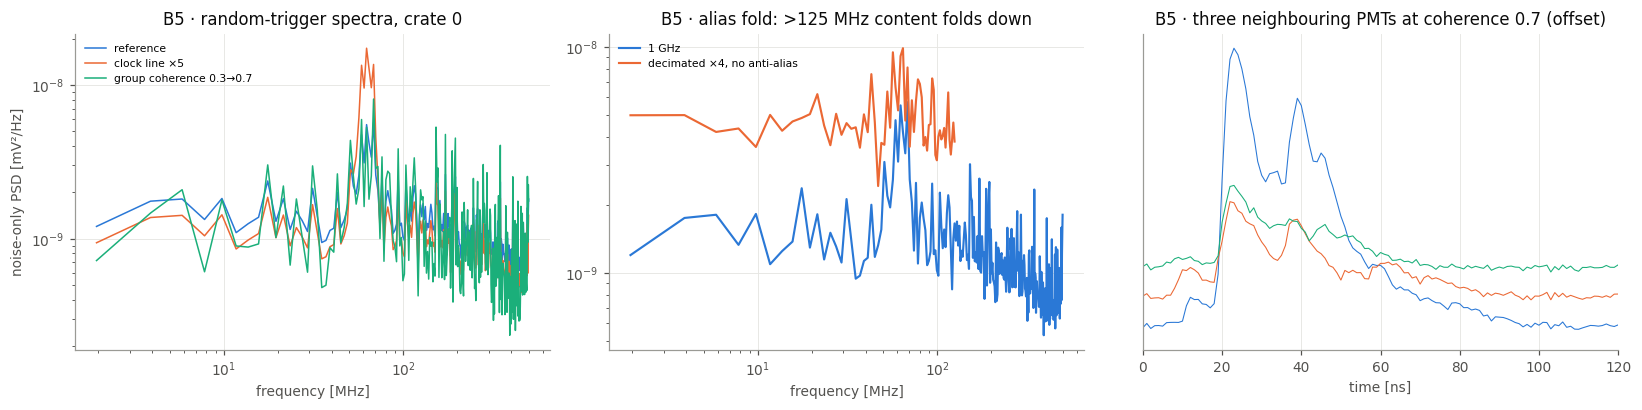

In [14]:
from copy import deepcopy
def variant(scale_line=None, corr=0.3, decimate=None):
    p = deepcopy(PMT_FRONTEND_V1)
    if scale_line: p["components"][3]["scale"] *= scale_line
    return p, corr

sigma_cells_L = {"reference": variant(), "clock line ×5": variant(scale_line=5.0), "group coherence 0.3→0.7": variant(corr=0.7)}
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
Sref_c = None
for i, (name, (preset, corr)) in enumerate(sigma_cells_L.items()):
    nz, groups = add_pmt_noise(np.zeros_like(sig_mv), preset, corr_strength=corr, seed=1)     # random triggers
    psd = np.mean(np.abs(rfft(nz[:GROUP], axis=-1)) ** 2, axis=0) * 2 / (FS_L * N_L)
    ax[0].loglog(fL[1:] / 1e6, psd[1:], color=PAL[i], lw=1.0, label=name)
    Cc = np.corrcoef(nz[:GROUP]); offd = Cc[np.triu_indices(GROUP, 1)].mean()
    if Sref_c is None: Sref_c = groups[0]["implied_covariance"]
    Wg = KroneckerWhitener(Sref_c / np.mean(np.diag(Sref_c)), S_pmt, FS_L, N_L)
    Sc_est, S_est = estimate_kronecker(nz[None, :GROUP], FS_L, psd_smoothing=9)
    k = Wg.kappa_against(Sc_est, S_est)
    print(f"{name:26s} mean off-diag corr (crate 0) = {offd:5.3f}   κ_channel={k['kappa_channel']:5.2f}  κ_temporal={k['kappa_temporal']:6.2f}")
ax[0].set_xlabel("frequency [MHz]"); ax[0].set_ylabel("noise-only PSD [mV²/Hz]"); ax[0].set_title("B5 · random-trigger spectra, crate 0"); ax[0].legend(frameon=False, fontsize=7)
# alias fold: decimate 1 GHz -> 250 MHz without an anti-alias filter (a digitiser-contract change)
nz_ref, _ = add_pmt_noise(np.zeros_like(sig_mv), PMT_FRONTEND_V1, seed=1)
dec = nz_ref[:, ::4]; fD = rfftfreq(dec.shape[1], d=4 / FS_L)
psd_dec = np.mean(np.abs(rfft(dec[:GROUP], axis=-1)) ** 2, axis=0) * 2 / (FS_L / 4 * dec.shape[1])
psd_ref = np.mean(np.abs(rfft(nz_ref[:GROUP], axis=-1)) ** 2, axis=0) * 2 / (FS_L * N_L)
ax[1].loglog(fL[1:] / 1e6, psd_ref[1:], color=PAL[0], label="1 GHz"); ax[1].loglog(fD[1:] / 1e6, psd_dec[1:], color=PAL[1], label="decimated ×4, no anti-alias")
ax[1].set_xlabel("frequency [MHz]"); ax[1].set_title("B5 · alias fold: >125 MHz content folds down"); ax[1].legend(frameon=False, fontsize=7)
tr_hi, _ = add_pmt_noise(sig_mv, sigma_cells_L["group coherence 0.3→0.7"][0], corr_strength=0.7, seed=1)
for j, c in enumerate(range(hot, hot + 3)):
    ax[2].plot(tns, tr_hi[c] + 12 * j, color=PAL[j], lw=0.7)
ax[2].set_xlim(0, 120); ax[2].set_xlabel("time [ns]"); ax[2].set_title("B5 · three neighbouring PMTs at coherence 0.7 (offset)"); ax[2].set_yticks([])
plt.tight_layout()

Read the κ values against the reference row again: on a **512-sample** record with **64 channels** the
matched-cell floor is κ_channel ≈ 5 — N/C is only 8, far below the ≳ 500 the arms plan asks for. This is
the concrete reason the LUCiD arm must use `window_ns` of 16–32 µs for its covariance cells: at the default
window the estimator cannot see a real mismatch under its own noise. The clock line and the coherence change
are still visible here because they are large.

How to read the three LUCiD noise cells:

* **Clock line ×5** — one narrow spike at 62.5 MHz grows; the rest of the spectrum and the channel correlation
  do not move. In the time domain it is a faint 16 ns ripple on every trace in the crate. This is the
  water-Cherenkov analogue of HeRALD's `mains_up`: a *line*, at a frequency the record can actually resolve.
* **Group coherence 0.3 → 0.7** — the per-channel spectrum is unchanged, but neighbouring PMTs now wiggle
  together (right panel): the correlation matrix within a crate fills in. κ_channel moves, κ_temporal does
  not — the same split as `bath_corr_up` in Part A.
* **Alias fold** — decimating 1 GHz → 250 MHz without an anti-alias filter folds everything above 125 MHz
  (the cable ring, the top of the amplifier band) back into the passband. Nothing was added; the *digitiser
  contract* changed, and the realised in-band spectrum is predicted in closed form by
  `noise_module.psd_resampling.alias_fold_psd_density`. It is the cleanest acquisition-side N family the
  arms plan names.

---
## What to take away

| you moved… | HeRALD showed | LUCiD showed | where it lives |
|---|---|---|---|
| the **event** (type, energy, vertex) | yield count, amplitude, pattern; arrival-time *shape* fixed | charge scale, charge pattern, first-light time | the clean signal only — random triggers unchanged |
| the **geometry** | same quasiparticles, different collection: 24 → 9 → 1 traces | same photons, different coverage: 2 444 → 800 PMTs, cylinder → box | the channel structure of the signal |
| the **noise** (covariance) | bath correlation, SQUID knee, mains line, pickup modes | crate coherence, clock line, alias fold | random-trigger spectra and correlations — the signal untouched |
| a **structural** acquisition change | sensor loss, gain drift, jitter | (same operators apply) | both the signal pattern *and* the random triggers |

That last column is the discriminator the monitoring lookup in `latent_monitor` is built on: a random
trigger cannot see physics. The companion notebook, `noise_models_herald_lucid.ipynb`, opens up each noise
term and says what it is physically.